# World Cup Image Colorization Autoencoder

This notebook builds a compact PyTorch autoencoder for World Cup image colorization. The simplified DDColor-inspired task uses the grayscale CIELAB lightness channel as input and predicts the missing chrominance channels.

The notebook installs its runtime dependencies inside the notebook because it is expected to run on a remote Jupyter server.

In [1]:
%pip install -q torch torchvision kornia pillow matplotlib tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 128.0 MB/s eta 0:00:00


In [2]:
from collections import Counter
from pathlib import Path
import random
from shutil import copyfile
from zipfile import ZipFile

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms.functional as TF
from kornia.color import lab_to_rgb, rgb_to_lab
from tqdm.auto import tqdm

assert torch.cuda.is_available(), "CUDA GPU is required"
device = torch.device("cuda")

# ZIP_PATH = Path("/content/drive/MyDrive/mu/MACC-2025-2026/GrupoBombo/POPBL/DeepLearning/images.zip")
ZIP_PATH = Path("/content/drive/MyDrive/tmp/images.zip")
LOCAL_ZIP = Path("/content/images.zip")
DATA_DIR = Path("/content/images")
# CHECKPOINT_PATH = Path("/content/drive/MyDrive/mu/MACC-2025-2026/GrupoBombo/POPBL/DeepLearning/world_cup_color_autoencoder.pt")
CHECKPOINT_PATH = Path("/content/drive/MyDrive/tmp/world_cup_color_autoencoder_v2.pt")
IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 5
LAMBDA_PIX = 1.0
LAMBDA_COL = 0.005  # Sensible, makes the model predict colorful garbage
LAMBDA_TV = 0.02
SEED = 42

random.seed(SEED)
torch.manual_seed(SEED)

## 01.- Defining the problem

The problem is World Cup image colorization. Given a grayscale input image $x_L \in \mathbb{R}^{H \times W \times 1}$, the network predicts $\hat{y}_{AB} \in \mathbb{R}^{H \times W \times 2}$. The original lightness channel and the predicted chrominance channels are then recombined in CIELAB space before conversion back to RGB.

![CIELAB.png](./assets/CIELAB.png)

The dataset zip file is imported from Google Drive, extracted into the Colab runtime, and discovered recursively from the extracted image folder.

In [3]:
from google.colab import drive

drive.mount("/content/drive", force_remount=True)
assert ZIP_PATH.exists(), f"Zip file not found: {ZIP_PATH}"
copyfile(ZIP_PATH, LOCAL_ZIP)
DATA_DIR.mkdir(parents=True, exist_ok=True)
with ZipFile(LOCAL_ZIP) as zf:
    zf.extractall(DATA_DIR)

image_exts = {".jpg", ".jpeg", ".png", ".webp"}
paths = sorted(p for p in DATA_DIR.rglob("*") if p.suffix.lower() in image_exts)
assert paths, f"No images found after extracting {ZIP_PATH}"
print(f"Images: {len(paths)}")

Mounted at /content/drive
Images: 152603


The EDA section keeps only concise dataset characteristics and a small visual sample.

Extensions: {'.jpg': 152603}
Width min/median/max: 1080/1920/1920
Height min/median/max: 1080/1080/1920


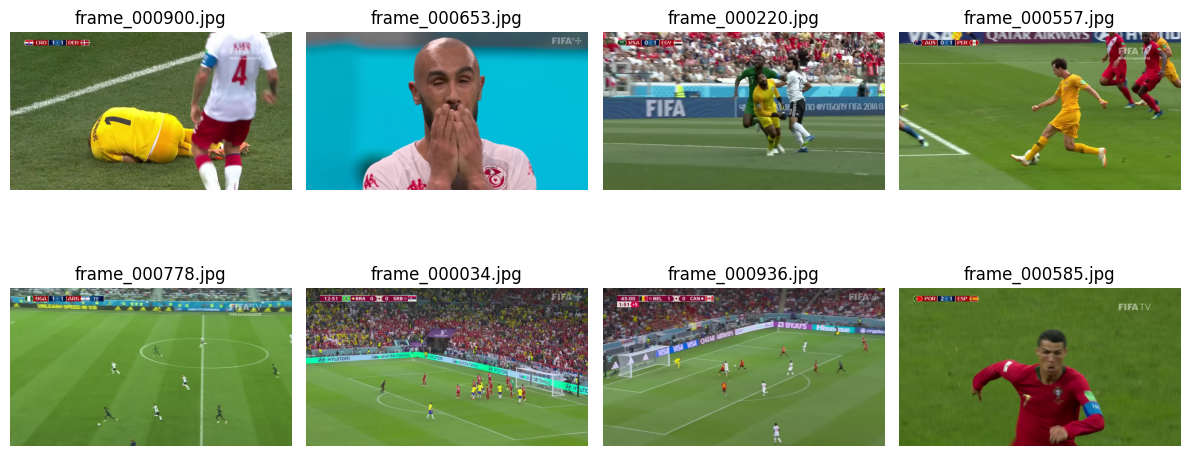

In [4]:
sizes = [Image.open(p).size for p in paths]
widths, heights = zip(*sizes)

print("Extensions:", dict(Counter(p.suffix.lower() for p in paths)))
print(f"Width min/median/max: {min(widths)}/{int(np.median(widths))}/{max(widths)}")
print(f"Height min/median/max: {min(heights)}/{int(np.median(heights))}/{max(heights)}")

n = min(8, len(paths))
sample_paths = random.sample(paths, n)
fig, axes = plt.subplots((n + 3) // 4, 4, figsize=(12, 3 * ((n + 3) // 4)))
axes = np.atleast_1d(axes).ravel()
for ax, p in zip(axes, sample_paths):
    ax.imshow(Image.open(p).convert("RGB"))
    ax.set_title(p.name[:28])
    ax.axis("off")
for ax in axes[n:]:
    ax.axis("off")
plt.tight_layout()

## 02.- Choosing a measure of success

The generator is optimized mainly with pixel loss plus a small chroma smoothness penalty. The colorfulness term is still available, but disabled by default because a large weight can reward saturated artifacts instead of correct colors. Model success is judged with held-out evaluation metrics rather than training loss.

The pixel loss is the L1 distance between predicted and ground-truth chrominance channels:

$$
\mathcal{L}_{pix} = \lVert \hat{y}_{AB} - y_{AB} \rVert_1
$$

The smoothness penalty discourages high-frequency checkerboard chroma:

$$
\mathcal{L}_{tv} = \lvert \nabla_x \hat{y}_{AB} \rvert + \lvert \nabla_y \hat{y}_{AB} \rvert
$$

The optional colorfulness loss encourages colorful RGB reconstructions when its weight is set above zero:

$$
\mathcal{L}_{col} = 1 - \frac{\sigma_{rgyb}(\hat{y}) + 0.3 \cdot \mu_{rgyb}(\hat{y})}{100}
$$

The final training objective is:

$$
\mathcal{L}_{\theta} = \lambda_{pix}\mathcal{L}_{pix} + \lambda_{tv}\mathcal{L}_{tv} + \lambda_{col}\mathcal{L}_{col}
$$

The held-out metrics are: normalized AB MAE, AB-plane DeltaE, and RGB PSNR.

## 03.- Deciding on an evaluation protocol

The image paths are split into train, validation, and test sets with an 80/10/10 ratio. Validation metrics are reported during training, and test metrics are reported once after training.

In [5]:
random.shuffle(paths)
train_end = int(0.8 * len(paths))
val_end = int(0.9 * len(paths))
train_paths, val_paths, test_paths = paths[:train_end], paths[train_end:val_end], paths[val_end:]
print(len(train_paths), len(val_paths), len(test_paths))

122082 15260 15261


## 04.- Preparing the data

The data pipeline resizes each image, applies horizontal flip augmentation only to training samples, converts RGB to CIELAB, and separates normalized L and AB tensors.

In [6]:
class WorldCupColorDataset(Dataset):
    def __init__(self, paths, train=False):
        self.paths = paths
        self.train = train

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, index):
        image = Image.open(self.paths[index]).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
        rgb = TF.to_tensor(image)
        if self.train and torch.rand(()) < 0.5:
            rgb = TF.hflip(rgb)
        lab = rgb_to_lab(rgb.unsqueeze(0)).squeeze(0)
        return lab[:1] / 50 - 1, lab[1:] / 128


train_loader = DataLoader(WorldCupColorDataset(train_paths, True), BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(WorldCupColorDataset(val_paths), BATCH_SIZE, num_workers=2, pin_memory=True)
test_loader = DataLoader(WorldCupColorDataset(test_paths), BATCH_SIZE, num_workers=2, pin_memory=True)

L_batch, AB_batch = next(iter(train_loader))
print(L_batch.shape, AB_batch.shape)

torch.Size([32, 1, 128, 128]) torch.Size([32, 2, 128, 128])


## 05.- Developing the autoencoder architecture

The autoencoder receives normalized grayscale L tensors with shape $[B, 1, H, W]$ and predicts normalized AB tensors with shape $[B, 2, H, W]$.

In [7]:
class ColorAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 64, 3, 2, 1), nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, 3, 2, 1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 256, 3, 2, 1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(256, 128, 3, 1, 1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(128, 64, 3, 1, 1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(64, 32, 3, 1, 1), nn.ReLU(inplace=True),
            nn.Conv2d(32, 2, 3, 1, 1), nn.Tanh(),
        )

    def forward(self, L):
        return self.net(L)


def lab_channels_to_rgb(L, AB):
    return lab_to_rgb(torch.cat([(L + 1) * 50, AB * 128], dim=1)).clamp(0, 1)


def colorfulness_loss(rgb):
    r, g, b = (rgb * 255).unbind(1)
    rg = (r - g).flatten(1)
    yb = (0.5 * (r + g) - b).flatten(1)
    sigma = torch.sqrt(rg.var(1, unbiased=False) + yb.var(1, unbiased=False))
    mu = torch.sqrt(rg.mean(1).pow(2) + yb.mean(1).pow(2))
    return (1 - (sigma + 0.3 * mu) / 100).mean()


def total_variation_loss(x):
    return (x[:, :, :, 1:] - x[:, :, :, :-1]).abs().mean() + (x[:, :, 1:, :] - x[:, :, :-1, :]).abs().mean()


def objective_loss(L, pred_AB, AB):
    loss = LAMBDA_PIX * F.l1_loss(pred_AB, AB)
    loss = loss + LAMBDA_TV * total_variation_loss(pred_AB)
    if LAMBDA_COL:
        loss = loss + LAMBDA_COL * colorfulness_loss(lab_channels_to_rgb(L, pred_AB))
    return loss


model = ColorAutoencoder().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)
CHECKPOINT_PATH.parent.mkdir(parents=True, exist_ok=True)
start_epoch = 1
history = []
if CHECKPOINT_PATH.exists():
    # This checkpoint is created by this notebook and includes optimizer/history metadata.
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint["model"])
    optimizer.load_state_dict(checkpoint["optimizer"])
    history = checkpoint.get("history", [])
    start_epoch = checkpoint["epoch"] + 1
    print(f"Resuming from epoch {start_epoch}")

The evaluation function computes metrics on held-out data and keeps training loss separate from the success measure.

In [8]:
@torch.no_grad()
def evaluate(loader):
    model.eval()
    total = loss_total = ab_mae = deltae_ab = mse = 0
    for L, AB in loader:
        L, AB = L.to(device), AB.to(device)
        pred_AB = model(L)
        loss = objective_loss(L, pred_AB, AB)
        pred_AB = pred_AB.clamp(-1, 1)
        pred_rgb = lab_channels_to_rgb(L, pred_AB)
        true_rgb = lab_channels_to_rgb(L, AB)
        batch = L.size(0)
        loss_total += loss.item() * batch
        ab_mae += (pred_AB - AB).abs().mean((1, 2, 3)).sum().item()
        deltae_ab += torch.sqrt(((pred_AB - AB) * 128).pow(2).sum(1)).mean((1, 2)).sum().item()
        mse += F.mse_loss(pred_rgb, true_rgb, reduction="none").mean((1, 2, 3)).sum().item()
        total += batch
    mse /= total
    return {"loss": loss_total / total, "ab_mae": ab_mae / total, "deltae_ab": deltae_ab / total, "psnr": float(-10 * np.log10(mse + 1e-8))}

The training loop optimizes the reconstruction objective, reports validation metrics after each epoch, and stores a checkpoint for interrupted sessions.

In [9]:
for epoch in range(start_epoch, EPOCHS + 1):
    model.train()
    train_loss = 0
    total = 0
    for L, AB in tqdm(train_loader, desc=f"epoch {epoch}/{EPOCHS}"):
        L, AB = L.to(device), AB.to(device)
        pred_AB = model(L)
        loss = objective_loss(L, pred_AB, AB)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * L.size(0)
        total += L.size(0)
    metrics = evaluate(val_loader)
    train_loss /= total
    history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": metrics["loss"], "val_ab_mae": metrics["ab_mae"], "val_deltae_ab": metrics["deltae_ab"], "val_psnr": metrics["psnr"]})
    print(f"epoch {epoch}: train_loss={train_loss:.4f}, val_loss={metrics['loss']:.4f}, val_ab_mae={metrics['ab_mae']:.4f}, val_deltae_ab={metrics['deltae_ab']:.2f}, val_psnr={metrics['psnr']:.2f}")
    torch.save({"epoch": epoch, "model": model.state_dict(), "optimizer": optimizer.state_dict(), "history": history}, CHECKPOINT_PATH)
    print(f"checkpoint: {CHECKPOINT_PATH}") 

epoch 1/5:   0%|          | 0/3816 [00:00<?, ?it/s]

epoch 1: train_loss=0.0720, val_loss=0.0681, val_ab_mae=0.0648, val_deltae_ab=13.11, val_psnr=21.19
checkpoint: /content/drive/MyDrive/tmp/world_cup_color_autoencoder_v2.pt


epoch 2/5:   0%|          | 0/3816 [00:00<?, ?it/s]

epoch 2: train_loss=0.0670, val_loss=0.0658, val_ab_mae=0.0626, val_deltae_ab=12.67, val_psnr=21.35
checkpoint: /content/drive/MyDrive/tmp/world_cup_color_autoencoder_v2.pt


epoch 3/5:   0%|          | 0/3816 [00:00<?, ?it/s]

epoch 3: train_loss=0.0649, val_loss=0.0644, val_ab_mae=0.0611, val_deltae_ab=12.39, val_psnr=21.54
checkpoint: /content/drive/MyDrive/tmp/world_cup_color_autoencoder_v2.pt


epoch 4/5:   0%|          | 0/3816 [00:00<?, ?it/s]

epoch 4: train_loss=0.0636, val_loss=0.0634, val_ab_mae=0.0602, val_deltae_ab=12.16, val_psnr=21.58
checkpoint: /content/drive/MyDrive/tmp/world_cup_color_autoencoder_v2.pt


epoch 5/5:   0%|          | 0/3816 [00:00<?, ?it/s]

epoch 5: train_loss=0.0627, val_loss=0.0630, val_ab_mae=0.0599, val_deltae_ab=12.16, val_psnr=21.63
checkpoint: /content/drive/MyDrive/tmp/world_cup_color_autoencoder_v2.pt


The learning curves compare training and validation objective losses so overfitting can be inspected visually.

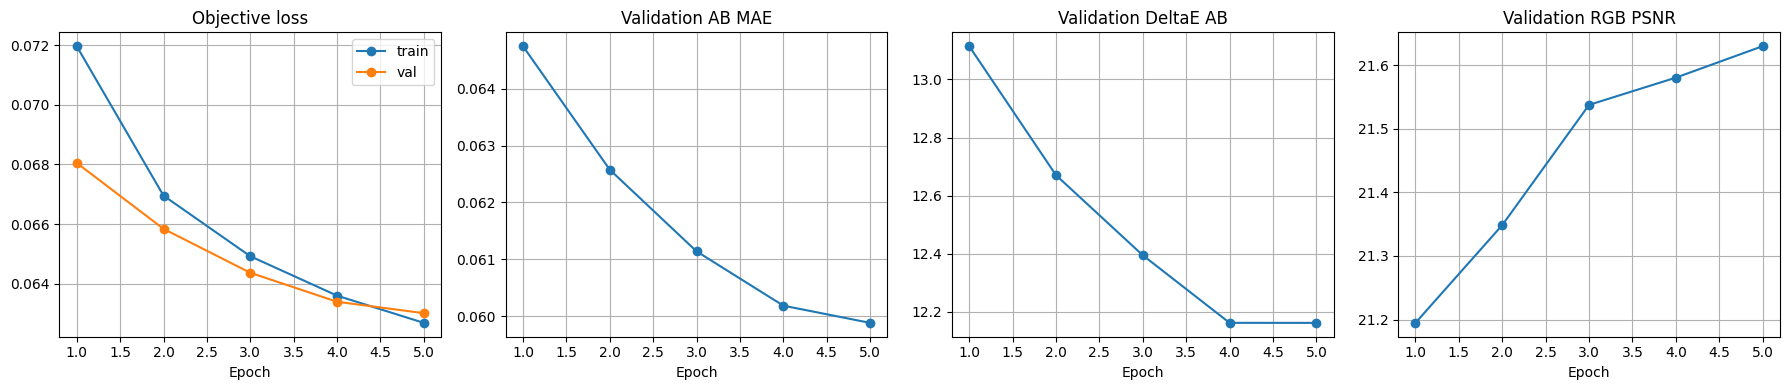

In [10]:
epochs = [h["epoch"] for h in history]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].plot(epochs, [h["train_loss"] for h in history], marker="o", label="train")
axes[0].plot(epochs, [h["val_loss"] for h in history], marker="o", label="val")
axes[0].set_title("Objective loss")
axes[0].legend()

axes[1].plot(epochs, [h["val_ab_mae"] for h in history], marker="o")
axes[1].set_title("Validation AB MAE")

axes[2].plot(epochs, [h["val_deltae_ab"] for h in history], marker="o")
axes[2].set_title("Validation DeltaE AB")

axes[3].plot(epochs, [h["val_psnr"] for h in history], marker="o")
axes[3].set_title("Validation RGB PSNR")

for ax in axes:
    ax.set_xlabel("Epoch")
    ax.grid(True)

plt.tight_layout()

## 06.- Final model testing

The final test section reports held-out metrics and displays grayscale input, predicted colorization, and ground truth images.

test_ab_mae=0.0606, test_deltae_ab=12.30, test_psnr=21.49


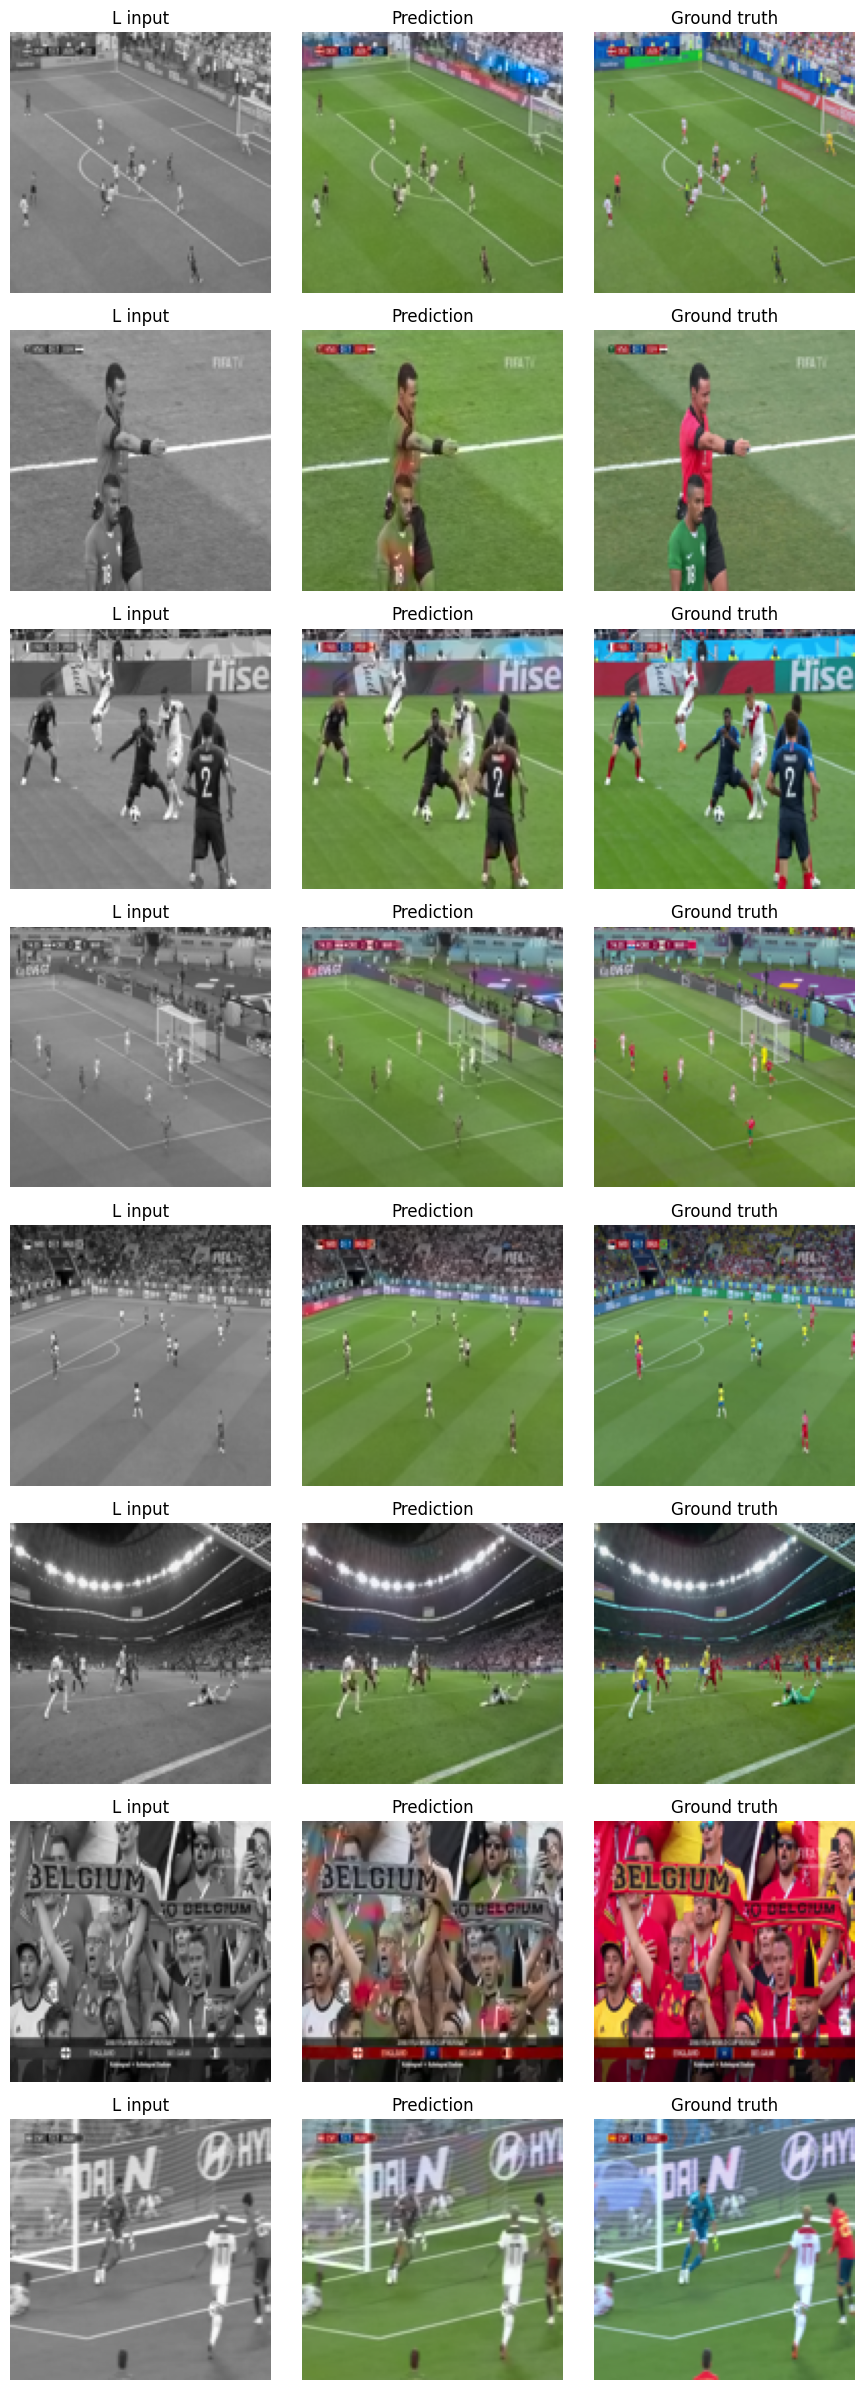

In [11]:
test_metrics = evaluate(test_loader)
print(f"test_ab_mae={test_metrics['ab_mae']:.4f}, test_deltae_ab={test_metrics['deltae_ab']:.2f}, test_psnr={test_metrics['psnr']:.2f}")

model.eval()
L, AB = next(iter(test_loader))
L, AB = L[:8].to(device), AB[:8].to(device)
with torch.no_grad():
    pred_AB = model(L).clamp(-1, 1)
    gray_rgb = lab_channels_to_rgb(L, torch.zeros_like(pred_AB)).cpu()
    pred_rgb = lab_channels_to_rgb(L, pred_AB).cpu()
    true_rgb = lab_channels_to_rgb(L, AB).cpu()

rows = L.size(0)
fig, axes = plt.subplots(rows, 3, figsize=(9, 3 * rows))
axes = np.atleast_2d(axes)
for i in range(rows):
    for ax, image, title in zip(axes[i], [gray_rgb[i], pred_rgb[i], true_rgb[i]], ["L input", "Prediction", "Ground truth"]):
        ax.imshow(image.permute(1, 2, 0))
        ax.set_title(title)
        ax.axis("off")
plt.tight_layout()

Loaded checkpoint: /content/drive/MyDrive/tmp/world_cup_color_autoencoder_v2.pt


Colorized 6 image(s). Saved outputs to: /content/drive/MyDrive/tmp/test_images_colorized


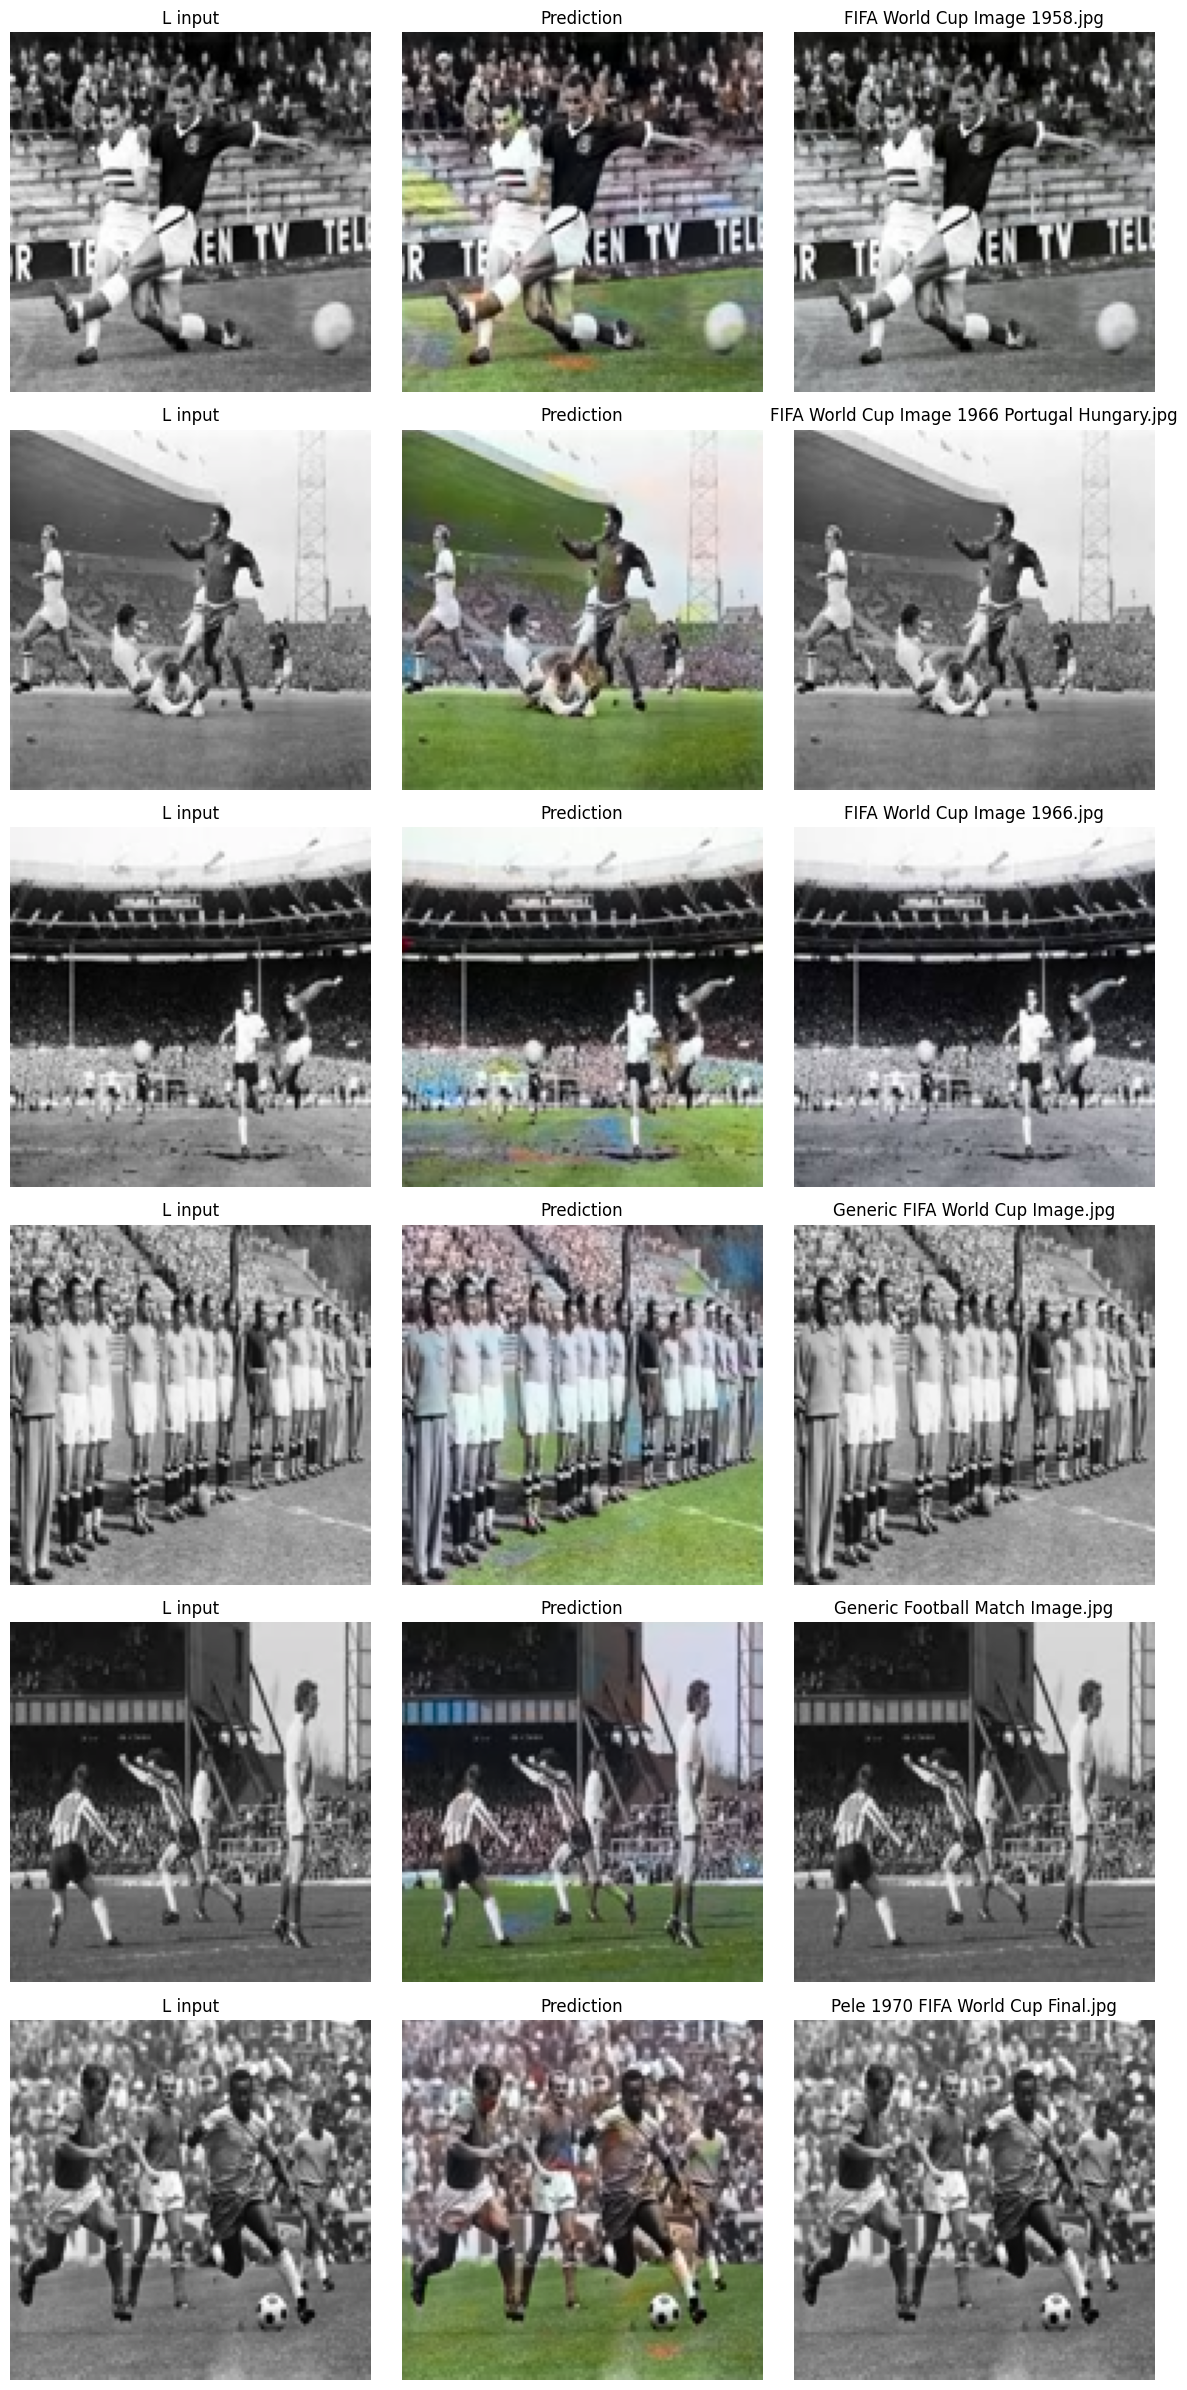

In [14]:
INFERENCE_DIR = Path("/content/drive/MyDrive/tmp/test_images")
OUTPUT_DIR = Path("/content/drive/MyDrive/tmp/test_images_colorized")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if not INFERENCE_DIR.exists():
    raise FileNotFoundError(
        f"Could not find {INFERENCE_DIR.resolve()}. "
        "Run this notebook from the repository root or update INFERENCE_DIR."
    )

if CHECKPOINT_PATH.exists():
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint["model"])
    print(f"Loaded checkpoint: {CHECKPOINT_PATH}")

image_exts = {".jpg", ".jpeg", ".png", ".webp"}
inference_paths = sorted(
    p for p in INFERENCE_DIR.rglob("*")
    if p.suffix.lower() in image_exts
)

assert inference_paths, f"No images found under {INFERENCE_DIR}"

model.eval()
results = []

for path in inference_paths:
    original = Image.open(path).convert("RGB")
    original_size = original.size

    rgb = TF.to_tensor(original.resize((IMG_SIZE, IMG_SIZE))).unsqueeze(0).to(device)
    lab = rgb_to_lab(rgb)
    L = lab[:, :1] / 50 - 1

    with torch.no_grad():
        pred_AB = model(L).clamp(-1, 1)
        gray_rgb = lab_channels_to_rgb(L, torch.zeros_like(pred_AB)).cpu()[0]
        pred_rgb = lab_channels_to_rgb(L, pred_AB).cpu()[0]

    pred_image = TF.to_pil_image(pred_rgb).resize(original_size)
    out_path = OUTPUT_DIR / f"{path.stem}_colorized.png"
    pred_image.save(out_path)

    results.append((path, gray_rgb, pred_rgb, original.resize((IMG_SIZE, IMG_SIZE)), out_path))

print(f"Colorized {len(results)} image(s). Saved outputs to: {OUTPUT_DIR.resolve()}")

rows = len(results)
fig, axes = plt.subplots(rows, 3, figsize=(12, 4 * rows))

if rows == 1:
    axes = np.expand_dims(axes, axis=0)

for row, (path, gray_rgb, pred_rgb, original_rgb, out_path) in enumerate(results):
    axes[row, 0].imshow(gray_rgb.permute(1, 2, 0))
    axes[row, 0].set_title("L input")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(pred_rgb.permute(1, 2, 0))
    axes[row, 1].set_title("Prediction")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(original_rgb)
    axes[row, 2].set_title(path.name)
    axes[row, 2].axis("off")

plt.tight_layout()